In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

In [1]:
import pandas as pd # 파일입력(read_excel), 교차표(crosstab), 원핫인코딩(get_dummies)
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split # 훈련셋과 시험셋 분리 함수
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, save_model, load_model
# 과적합을 줄이기 위한 방법 : dropout, 배치정규화, L2정규화
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
# 데이터 불균형 극복 5.5 : 4.5 => 5:5
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt # 모델 학습과정 살펴보기
from sklearn.metrics import confusion_matrix # 혼동행렬

```
age: 나이 (년 단위)
sex: 성별 (1 = 남성, 0 = 여성)
cp (Chest Pain Type): 흉통의 유형 (0~3 값, 일반 협심증부터 무증상까지 분류)
trestbps: 안정 시 혈압 (mmHg)
chol: 혈청 콜레스테롤 수치 (mg/dl)
fbs (Fasting Blood Sugar): 공복 혈당이 120 mg/dl 초과인지 여부 (1 = 참, 0 = 거짓)
restecg: 안정 시 심전도(ECG) 결과 (0~2)
thalach: 운동 시 달성한 최대 심박수
exang: 운동 유발 협심증 여부 (1 = 있음, 0 = 없음)
oldpeak: 휴식기에 비해 운동 시 나타나는 ST 부위 하강(ST depression) 정도
slope: 최고 운동 시 ST 세그먼트의 기울기ca: 형광투시법으로 색칠된 주요 혈관 수 (0~3개)
thal: 지중해빈혈 등 혈액 질환 여부 (정상, 고정 결함, 가역적 결함 등)
target (Diagnosis): 심장질환 진단 결과 (0 = 정상, 1 = 심장질환 있음)
```

# 이진분류(로지스틱 회귀분석)
- 1. 데이터셋 생성 & 전처리
    * 엑셀 -> 데이터프레임 -> ?처리(결측치로 전환하여 결측치처리) -> X, y분리
        -> X변수의 scale조정 -> train_test_split()을 이용하여 학습셋과 테스트셋을 분리
- 2. 모델 생성(입력13,타겟1) - 과적합 고려 & 학습과정설정 & 학습
- 3. 모델 평가(그래프, 평가, 혼동행렬=교차표)
- 4. 모델 사용

## 1. 데이터셋 생성 & 전처리

In [2]:
df = pd.read_excel('data/heart-disease.xlsx',
                  # sheet_name='processed.cleveland'
                  )
df.head()

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,0,108,1,1.5,2,3,3,1
2,67,1,4,120,?,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           303 non-null    int64  
 1   sex           303 non-null    int64  
 2   cp            303 non-null    int64  
 3   treshtbps     303 non-null    int64  
 4   chol          303 non-null    object 
 5   fbs           303 non-null    int64  
 6   restecg       303 non-null    int64  
 7   thalach       303 non-null    int64  
 8   exang         303 non-null    int64  
 9   oldpeak       303 non-null    float64
 10  slope         303 non-null    int64  
 11  ca            303 non-null    object 
 12  hsl           303 non-null    object 
 13  heartDisease  303 non-null    int64  
dtypes: float64(1), int64(10), object(3)
memory usage: 33.3+ KB


In [12]:
df.isnull().sum()

age             0
sex             0
cp              0
treshtbps       0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
hsl             0
heartDisease    0
dtype: int64

In [14]:
df.isin(['?']).sum()

age             0
sex             0
cp              0
treshtbps       0
chol            1
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              4
hsl             2
heartDisease    0
dtype: int64

In [5]:
df[(df['chol']=='?') | (df['ca']=='?') | (df['hsl']=='?') ]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
2,67,1,4,120,?,0,2,129,1,2.6,2,2,7,1
87,53,0,3,128,216,0,2,115,0,0.0,1,0,?,0
166,52,1,3,138,223,0,0,169,0,0.0,1,?,3,0
192,43,1,4,132,247,1,2,143,1,0.1,2,?,7,1
266,52,1,4,128,204,1,0,156,1,1.0,2,0,?,1
287,58,1,2,125,220,0,0,144,0,0.4,2,?,7,0
302,38,1,3,138,175,0,0,173,0,0.0,1,?,3,0


In [3]:
# 방법1 : ?가 있는 행을 삭제
drop_idx = df[(df['chol']=='?') | (df['ca']=='?') | (df['hsl']=='?') ].index # 삭제할 행
df = df.drop(drop_idx)

In [9]:
# 방법2:?를 결측치로 대체 => 결측치 삭제
df = df.replace('?', np.nan)
df[(df['chol']=='?') | (df['ca']=='?') | (df['hsl']=='?') ]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [27]:
# 결측치가 포함된 데이터 추출
df[df['chol'].isna() | df['ca'].isna() | df['hsl'].isna()]
df[df.isna().any(axis=1)]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease
2,67,1,4,120,NaN,0,2,129,1,2.6,2,2.0,7.0,1
87,53,0,3,128,216.0,0,2,115,0,0.0,1,0.0,NaN,0
166,52,1,3,138,223.0,0,0,169,0,0.0,1,NaN,3.0,0
192,43,1,4,132,247.0,1,2,143,1,0.1,2,NaN,7.0,1
266,52,1,4,128,204.0,1,0,156,1,1.0,2,0.0,NaN,1
287,58,1,2,125,220.0,0,0,144,0,0.4,2,NaN,7.0,0
302,38,1,3,138,175.0,0,0,173,0,0.0,1,NaN,3.0,0


In [31]:
# 결측치 처리 : 삭제(dropna) cf. fillna() apply()
df.dropna(how='any', inplace=True) # 결측치가 한열이라도 있으면 삭제
df[df.isna().any(axis=1)]

,age,sex,cp,treshtbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,hsl,heartDisease


In [10]:
df.isna().sum()

age             0
sex             0
cp              0
treshtbps       0
chol            0
fbs             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
hsl             0
heartDisease    0
dtype: int64

In [11]:
df.shape

(296, 14)

In [12]:
# 타겟변수 분포가 균형적인지
df['heartDisease'].value_counts()/df.shape[0]

0    0.540541
1    0.459459
Name: heartDisease, dtype: float64

In [13]:
df['heartDisease'].value_counts(normalize=True)

0    0.540541
1    0.459459
Name: heartDisease, dtype: float64

In [4]:
# X, y분리
X = df.iloc[:, :-1].values # 맨마지막 열을 제외한 부분을 numpy배열
y = df.iloc[:, -1:].to_numpy() # 2차원 numpy 배열
X.shape, y.shape

((296, 13), (296, 1))

In [5]:
# X변수의 scale조정
scaler = MinMaxScaler()
scaled_X = scaler.fit_transform(X)
print('원 데이터 :', X[0])
print('스케일 조정 데이터 :', scaled_X[0])

원 데이터 : [63 1 1 145 233 1 2 150 0 2.3 3 0 6]
스케일 조정 데이터 : [0.70833333 1.         0.         0.48113208 0.24429224 1.
 1.         0.60305344 0.         0.37096774 1.         0.
 0.75      ]


In [6]:
# scaled_X와 y를 학습데이터셋:테스트셋 = 8:2
X_train, X_test, y_train, y_test = train_test_split(scaled_X,
                                    y,
                                    #train_size=0.8,
                                    test_size=0.2,
                                    random_state=7, # seed값
                                    stratify=y) # 층화추출

In [17]:
# 심장병 음성/양성 비율(y, y_train, y_test)
print(pd.DataFrame(y).value_counts(normalize=True))
print(pd.DataFrame(y_train).value_counts(normalize=True))
print(pd.DataFrame(y_test).value_counts(normalize=True))

0    0.540541
1    0.459459
dtype: float64
0    0.542373
1    0.457627
dtype: float64
0    0.533333
1    0.466667
dtype: float64


In [7]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((236, 13), (236, 1), (60, 13), (60, 1))

## 2. 모델생성 & 학습과정 설정 & 학습
- 모델 : 13 -> 32 -> 16 -> 8 -> 1
- 학습과정을 시각화한 그래프를 보고 과적합 줄이기
- 과적합 줄이기 위한 방법
    * dropout : 학습할 때마다 일부 뉴런을 랜덤하게 끄기. 특정 뉴런 조합에 과하게 의존하는 것을 막아줘.
    * BatchNormalization(배치 정규화) : 각 층의 출력을 정규화해서 더 안정적이고 빠르게 수렴하도록 도와줌
    * L2 정규화(규제) : 가중치가 너무 커지지 않게 학습과정에서 미리 누름. 가중치가 크면 입력값이 살짝 바뀌어도 출력이 확 바뀜. 규제를세게(0.01) / 규제중간(0.001) / 규제약하게(0.0001)

In [26]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.regularizers import l2
model = Sequential(name='sequential')
model.add(Dense(units=32, input_dim=13, activation='relu', 
               kernel_regularizer=l2(0.001)))
model.add(BatchNormalization()) # 출력층의 정규화
model.add(Dropout(0.4))         # 40%를 랜덤하게 꺼서 과적합 방지
model.add(Dense(units=16, activation='relu', kernel_regularizer=l2(0.001) ))
model.add(BatchNormalization()) 
model.add(Dropout(0.4))
model.add(Dense(units=8, activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization()) 
model.add(Dropout(0.2))
model.add(Dense(units=1, activation='sigmoid'))
model.summary()
# Dense층 뒤에 배치정규화층에서의 파라미터 : Dense층(32) 출력갯수 * 4
    # ggamma(스케일) - 32 (학습됨)
    # beta(이동)     - 32 (학습됨)
    # moving_mean(이동평균) - 32 (학습안됨)
    # moving_variance(이동분산) - 32 (학습 안됨)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_20 (Dense)            (None, 32)                448       
                                                                 
 batch_normalization_6 (Batc  (None, 32)               128       
 hNormalization)                                                 
                                                                 
 dropout_6 (Dropout)         (None, 32)                0         
                                                                 
 dense_21 (Dense)            (None, 16)                528       
                                                                 
 batch_normalization_7 (Batc  (None, 16)               64        
 hNormalization)                                                 
                                                                 
 dropout_7 (Dropout)         (None, 16)                0

In [27]:
# 학습과정 설정
from tensorflow.keras.metrics import Recall, Precision, Accuracy
from tensorflow.keras.optimizers import Adam
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              # optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy', #Accuracy(name='accuracy'), 
                       Recall(name='recall'),        # 재현율(실제값 중심=1을 얼마나 잘 예측했는지)
                       Precision(name='precision')]) # 정밀도(예측값 중심=1이라고 예측한 것 중 얼마나 1인지)

In [42]:
# 클래스(0/1) 가중치 계산 (55:45 정도의 비율 => 50:50)
from sklearn.utils.class_weight import compute_class_weight
y_train_flat = y_train.flatten() #y_train.reshape(-1)
class_weight = compute_class_weight(
                class_weight='balanced',
                classes=np.unique(y_train_flat),
                y = y_train_flat )
print('class_weight :', class_weight)
class_weight_dict = dict(enumerate(class_weight))
print('학습시 가중치 조정값 :', class_weight_dict)
# y_train의 빈도수(0은?개, 1은?개)
values, counts = np.unique(y_train_flat, return_counts=True)
print('빈도수 :', dict(zip(values, counts)))
print(counts[0]*class_weight_dict[0], counts[1]*class_weight_dict[1])
# 빈도 분포
ratios = counts / counts.sum()
ratios

class_weight : [0.921875   1.09259259]
학습시 가중치 조정값 : {0: 0.921875, 1: 1.0925925925925926}
빈도수 : {0: 128, 1: 108}
118.0 118.0


array([0.54237288, 0.45762712])

In [ ]:
# callback 설정
# ReduceLROnPlateau : 성능이 정체되면  학습률(learing_rate)을 낮춰서 세밀하게 탐색
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [24]:
# 학습
hist = model.fit(X_train, y_train, # 학습데이터
                epochs=200, # 학습횟수
                validation_split=0.2, # 학습데이터에서 20%를 검증데이터로 사용 
                 
                verbose=2)

Epoch 1/200
6/6 - 1s - loss: 0.9891 - accuracy: 0.4521 - recall: 0.3793 - precision: 0.4024 - val_loss: 0.7538 - val_accuracy: 0.5208 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - 1s/epoch - 236ms/step
Epoch 2/200
6/6 - 0s - loss: 1.0212 - accuracy: 0.4468 - recall: 0.4253 - precision: 0.4066 - val_loss: 0.7504 - val_accuracy: 0.5208 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - 93ms/epoch - 16ms/step
Epoch 3/200
6/6 - 0s - loss: 0.8184 - accuracy: 0.5638 - recall: 0.4943 - precision: 0.5309 - val_loss: 0.7487 - val_accuracy: 0.5208 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - 86ms/epoch - 14ms/step
Epoch 4/200
6/6 - 0s - loss: 0.9009 - accuracy: 0.4734 - recall: 0.4138 - precision: 0.4286 - val_loss: 0.7462 - val_accuracy: 0.5208 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - 91ms/epoch - 15ms/step
Epoch 5/200
6/6 - 0s - loss: 0.8188 - accuracy: 0.5160 - recall: 0.4713 - precision: 0.4767 - val_loss: 0.7440 - val_accuracy: 0.5000 - val_recall: 0.000

Epoch 41/200
6/6 - 0s - loss: 0.6104 - accuracy: 0.7128 - recall: 0.6552 - precision: 0.7037 - val_loss: 0.6369 - val_accuracy: 0.6875 - val_recall: 0.7619 - val_precision: 0.6154 - 67ms/epoch - 11ms/step
Epoch 42/200
6/6 - 0s - loss: 0.5596 - accuracy: 0.7766 - recall: 0.7701 - precision: 0.7528 - val_loss: 0.6306 - val_accuracy: 0.6875 - val_recall: 0.7619 - val_precision: 0.6154 - 70ms/epoch - 12ms/step
Epoch 43/200
6/6 - 0s - loss: 0.6375 - accuracy: 0.7021 - recall: 0.6667 - precision: 0.6824 - val_loss: 0.6271 - val_accuracy: 0.6875 - val_recall: 0.7619 - val_precision: 0.6154 - 69ms/epoch - 12ms/step
Epoch 44/200
6/6 - 0s - loss: 0.5733 - accuracy: 0.7074 - recall: 0.7241 - precision: 0.6702 - val_loss: 0.6226 - val_accuracy: 0.6875 - val_recall: 0.7619 - val_precision: 0.6154 - 67ms/epoch - 11ms/step
Epoch 45/200
6/6 - 0s - loss: 0.5699 - accuracy: 0.7340 - recall: 0.7356 - precision: 0.7033 - val_loss: 0.6179 - val_accuracy: 0.6875 - val_recall: 0.7619 - val_precision: 0.6154 

Epoch 81/200
6/6 - 0s - loss: 0.4260 - accuracy: 0.8191 - recall: 0.7816 - precision: 0.8193 - val_loss: 0.5080 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - 85ms/epoch - 14ms/step
Epoch 82/200
6/6 - 0s - loss: 0.5029 - accuracy: 0.7872 - recall: 0.7816 - precision: 0.7640 - val_loss: 0.5066 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - 70ms/epoch - 12ms/step
Epoch 83/200
6/6 - 0s - loss: 0.4725 - accuracy: 0.8298 - recall: 0.7816 - precision: 0.8395 - val_loss: 0.5073 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - 67ms/epoch - 11ms/step
Epoch 84/200
6/6 - 0s - loss: 0.5328 - accuracy: 0.7926 - recall: 0.7356 - precision: 0.8000 - val_loss: 0.5086 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 - 63ms/epoch - 10ms/step
Epoch 85/200
6/6 - 0s - loss: 0.4755 - accuracy: 0.7979 - recall: 0.7701 - precision: 0.7882 - val_loss: 0.5081 - val_accuracy: 0.7917 - val_recall: 0.7619 - val_precision: 0.7619 

Epoch 121/200
6/6 - 0s - loss: 0.3977 - accuracy: 0.8457 - recall: 0.8621 - precision: 0.8152 - val_loss: 0.5321 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - 72ms/epoch - 12ms/step
Epoch 122/200
6/6 - 0s - loss: 0.4819 - accuracy: 0.8032 - recall: 0.7931 - precision: 0.7841 - val_loss: 0.5313 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - 82ms/epoch - 14ms/step
Epoch 123/200
6/6 - 0s - loss: 0.3596 - accuracy: 0.8511 - recall: 0.8391 - precision: 0.8391 - val_loss: 0.5337 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - 75ms/epoch - 12ms/step
Epoch 124/200
6/6 - 0s - loss: 0.4454 - accuracy: 0.8138 - recall: 0.7816 - precision: 0.8095 - val_loss: 0.5377 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.8333 - 83ms/epoch - 14ms/step
Epoch 125/200
6/6 - 0s - loss: 0.3880 - accuracy: 0.8777 - recall: 0.8276 - precision: 0.9000 - val_loss: 0.5413 - val_accuracy: 0.8125 - val_recall: 0.7143 - val_precision: 0.

Epoch 161/200
6/6 - 0s - loss: 0.4111 - accuracy: 0.8564 - recall: 0.8046 - precision: 0.8750 - val_loss: 0.5536 - val_accuracy: 0.7917 - val_recall: 0.7143 - val_precision: 0.7895 - 73ms/epoch - 12ms/step
Epoch 162/200
6/6 - 0s - loss: 0.3732 - accuracy: 0.8830 - recall: 0.8736 - precision: 0.8736 - val_loss: 0.5563 - val_accuracy: 0.7917 - val_recall: 0.7143 - val_precision: 0.7895 - 73ms/epoch - 12ms/step
Epoch 163/200
6/6 - 0s - loss: 0.4220 - accuracy: 0.8298 - recall: 0.7931 - precision: 0.8313 - val_loss: 0.5557 - val_accuracy: 0.7917 - val_recall: 0.7143 - val_precision: 0.7895 - 74ms/epoch - 12ms/step
Epoch 164/200
6/6 - 0s - loss: 0.4034 - accuracy: 0.8564 - recall: 0.8506 - precision: 0.8409 - val_loss: 0.5527 - val_accuracy: 0.7917 - val_recall: 0.7143 - val_precision: 0.7895 - 68ms/epoch - 11ms/step
Epoch 165/200
6/6 - 0s - loss: 0.4063 - accuracy: 0.8457 - recall: 0.8046 - precision: 0.8537 - val_loss: 0.5549 - val_accuracy: 0.7917 - val_recall: 0.7143 - val_precision: 0.

# 3. 모델 평가(그래프, 평가, 교차표)

In [17]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'recall', 'precision', 'val_loss', 'val_accuracy', 'val_recall', 'val_precision'])

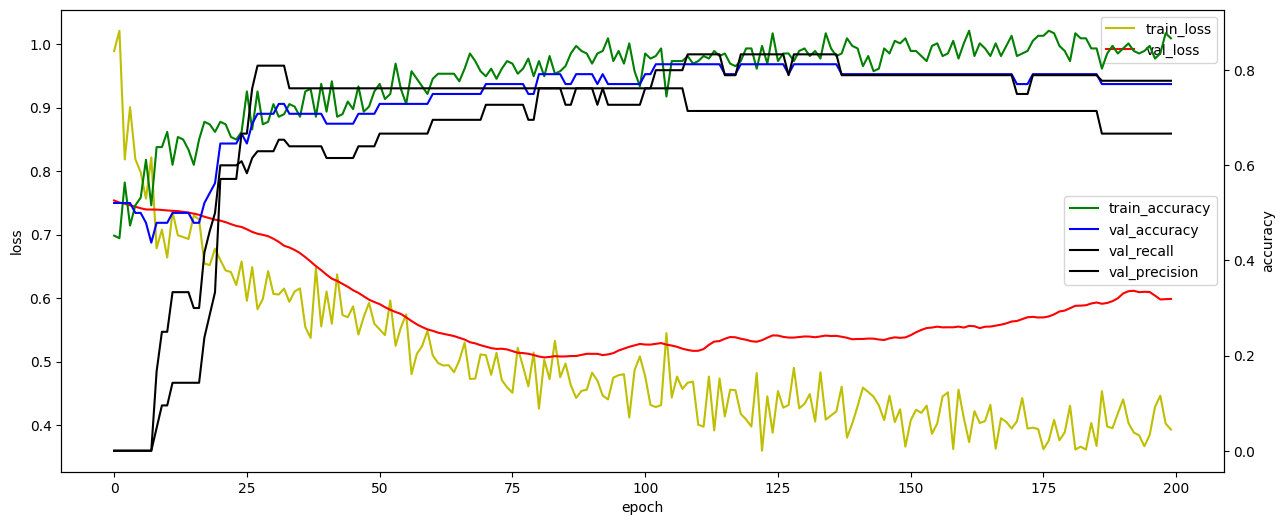

In [25]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')
acc_ax.plot(hist.history['val_recall'], 'k', label='val_recall') # recall(검정)
acc_ax.plot(hist.history['val_precision'], 'k', label='val_precision') # precision(검정)

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()